In [185]:
import sys
sys.path.append('../lib')
import numpy as np
import healpy as hp
import pymaster as nmt
import matplotlib.pyplot as plt
import analys_lib as an
from scipy.ndimage import gaussian_filter
import fitlib as ftl
import covlib as cvl

In [186]:
# Inputs

nside = 64
lmax = 2*nside-1
fsky = 0.7
scale = 10
Nlbin = 10
dusttype = 'b'
synctype = 'b'
Pathload = '/pscratch/sd/s/svinzl/B_modes_project/'
N = 250
cov_type = 'Nmt-fg'
kw = ''
kws = ''
dusttype_cov = dusttype
synctype_cov = synctype
gaussbeam = True
bandpass = True
Ngrid = 50
cmb_e2e = True
n_iter = 3
adaptative = False
pl_moms = False
HVTWD = False
global_r = False
gnilc = False
kwv = '_v1' # should be '' or '_v1'
betabar = 1.48
tempbar = 19.6
betasbar = -3.1
nu0d = 402
nu0s = 40
FM_only = False
HM_only = False

if gaussbeam:
    kws += '_gaussbeam'
if bandpass:
    kws += '_bandpass'
if FM_only:
    kws += '_FM'
if HM_only:
    kws += '_HM'

if adaptative:
    kw += '_adaptative'

# Instrument

instr_name = 'litebird_full'
instr = np.load('../lib/instr_dict/%s.npy'%instr_name, allow_pickle=True).item()
freq = instr['frequencies']
if HM_only:
    freq = np.tile(freq, 2)
N_freqs = len(freq)
Ncross = int(N_freqs * (N_freqs+1)/2)

if bandpass:
    bw = instr['bandwidths']
    if HM_only:
        bw = np.tile(bw, 2)
    freq_grids = np.zeros((N_freqs, Ngrid))
    for i in range(N_freqs):
        freq_grids[i] = np.geomspace(freq[i]-bw[i]/2, freq[i]+bw[i]/2, Ngrid)
    freq = freq_grids

freq_pairs = np.array([(i, j) for i in range(N_freqs) for j in range(i, N_freqs)])
nu_i = freq[freq_pairs[:, 0]]
nu_j = freq[freq_pairs[:, 1]]

# Binning scheme

b = nmt.NmtBin.from_lmax_linear(lmax=lmax, nlb=Nlbin, is_Dell=True)
leff = b.get_effective_ells()
Nbins = len(leff)

In [187]:
# Initialize the fits

data = np.load(Pathload+'/power_spectra/DLcross_nside%s_fsky%s_scale%s_Nlbin%s_d%ss%sc' % (nside, fsky, scale, Nlbin, dusttype, synctype)+kws+'.npy')[:, :, :Nbins]
covmat = np.load(Pathload+'covariances/cov_%s_nside%s_fsky%s_scale%s_Nlbin%s_d%ss%sc' % (cov_type, nside, fsky, scale, Nlbin, dusttype_cov, synctype_cov)+kws+'.npy')[:Ncross*Nbins, :Ncross*Nbins]
results = np.load('../best_fits/results_d%ss%s_%s_scale%s_Nlbin%s_%s%s_ds_o1bts%s_analytical.npy' % (dusttype, synctype, fsky, scale, Nlbin, cov_type, kws, kw), allow_pickle=True).item()

betabar = np.mean(results['beta_d'])
tempbar = np.mean(results['T_d'])
betasbar = np.mean(results['beta_s'])

comp = [['A', 'As', 'Asd', 'Aw1b', 'Aw1t', 'w1bw1b', 'w1tw1t', 'w1bw1t', 'Asw1bs', 'w1bsw1bs', 'Asw1b', 'Asw1t', 'Aw1bs', 'w1bw1bs', 'w1tw1bs', 'cmb']
           for i in range(Nbins)]

gauss = an.gauss_like(freq, leff, covmat, comp, betabar, tempbar, betasbar, nu0d, nu0s)
W = gauss.W

In [188]:
W.shape

(192, 3036)

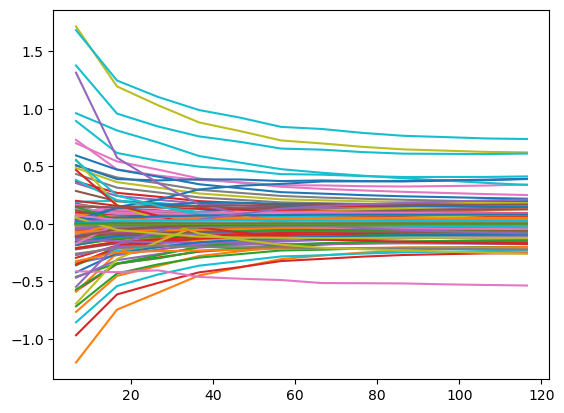

In [189]:
w_nu_ell = np.zeros((Ncross, Nbins))

for i in range(Ncross):
    for j, c in enumerate(np.concatenate(comp)):
        if c == 'cmb':
            w_nu_ell[i] += W[j, i + np.arange(Nbins)*Ncross]

w2_nu_ell = np.zeros((Ncross, Nbins))

for i in range(Ncross):
    l = 0
    for j, c in enumerate(np.concatenate(comp)):
        if c == 'cmb':
            w2_nu_ell[i, l] = W[j, i+l*Ncross]
            l += 1

plt.figure(figsize=(6.4, 4.8))
for i in range(Ncross):
    plt.plot(leff, w2_nu_ell[i])
plt.show()

In [190]:
w2_nu_ell.shape

(253, 12)

In [191]:
np.sum(w2_nu_ell, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

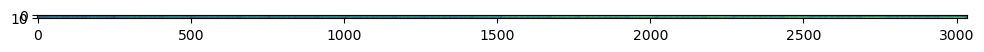

In [192]:
W_cmb = np.zeros((Nbins, Ncross*Nbins))
l = 0
for i, c in enumerate(np.concatenate(comp)):
    if c == 'cmb':
        W_cmb[l] = W[i]
        l += 1

plt.imshow(np.log(np.abs(W_cmb)))
plt.show()

In [193]:
W_cmb.shape

(12, 3036)

In [194]:
W_nu_ell = np.zeros((Nbins, Ncross))
for i in range(Nbins):
    W_nu_ell[i] = W_cmb[i, i*Ncross : (i+1)*Ncross]
W_nu_ell = W_nu_ell.T

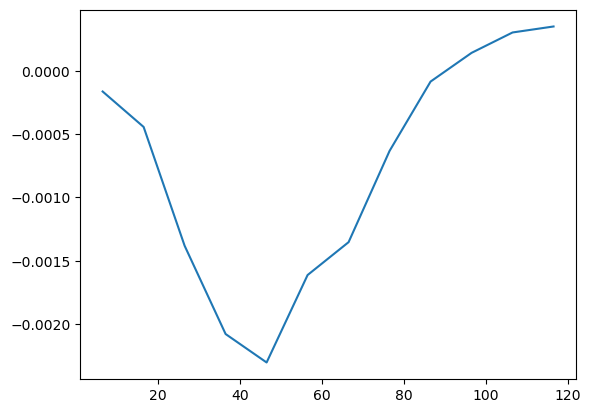

In [195]:
plt.figure(figsize=(6.4, 4.8))
for i in range(1):
    plt.plot(leff, W_nu_ell[i])
plt.show()

In [196]:
np.sum(W_nu_ell, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [197]:
W_nu_ell.shape

(253, 12)

In [198]:
data.shape

(250, 253, 12)

In [199]:
Cl_cmb = np.zeros((N, Nbins))

for k in range(N):
    for i in range(Nbins):
        Cl_cmb[k, i] = np.sum(W_nu_ell[:, i] * data[k, :, i])

In [200]:
np.mean(Cl_cmb, axis=0)

array([9.10072332e-05, 8.53479951e-05, 2.04467699e-04, 4.06943026e-04,
       6.01238006e-04, 8.87238826e-04, 1.28922148e-03, 1.70849411e-03,
       2.26889099e-03, 2.78811774e-03, 3.22922971e-03, 3.81247376e-03])

In [201]:
np.std(Cl_cmb, axis=0)

array([0.00064699, 0.00015192, 0.00023474, 0.0003255 , 0.00041416,
       0.00056052, 0.00073699, 0.00083639, 0.00092029, 0.00112587,
       0.00140755, 0.00160914])

In [202]:
np.mean(Cl_cmb, axis=0) / np.std(Cl_cmb, axis=0)

array([0.14066323, 0.5618069 , 0.87104664, 1.25021285, 1.45169109,
       1.58289929, 1.74930476, 2.04269578, 2.46542109, 2.47641268,
       2.29421472, 2.36926602])

In [203]:
np.mean(results['cmb'], axis=1) / np.std(results['cmb'], axis=1)

array([0.14011485, 0.55684591, 0.87149195, 1.24931908, 1.4520409 ,
       1.58290894, 1.74870898, 2.04202582, 2.4657453 , 2.47696126,
       2.29454829, 2.36926765])

In [204]:
# Unbinned/smoothed weights

sigma = 2.5

b1 = nmt.NmtBin.from_lmax_linear(lmax=lmax, nlb=1, is_Dell=True)
ell = b1.get_effective_ells()
Nell = len(ell)
data1 = np.load(Pathload+'/power_spectra/DLcross_nside%s_fsky%s_scale%s_Nlbin%s_d%ss%sc' % (nside, fsky, scale, 1, dusttype, synctype)+kws+'.npy')[:, :, :Nell]
results1 = np.load('../best_fits/results_d%ss%s_%s_scale%s_Nlbin%s_%s%s_ds_o1bts%s_analytical.npy' % (dusttype, synctype, fsky, scale, 1, cov_type, kws, kw), allow_pickle=True).item()

W1 = np.load('weights_nlb1.npy')
comp = [['A', 'As', 'Asd', 'Aw1b', 'Aw1t', 'w1bw1b', 'w1tw1t', 'w1bw1t', 'Asw1bs', 'w1bsw1bs', 'Asw1b', 'Asw1t', 'Aw1bs', 'w1bw1bs', 'w1tw1bs', 'cmb']
           for i in range(Nell)]

W1_cmb = np.zeros((Nell, Ncross*Nell))
l = 0
for i, c in enumerate(np.concatenate(comp)):
    if c == 'cmb':
        W1_cmb[l] = W1[i]
        l += 1

W1_nu_ell = np.zeros((Ncross, Nell))
for i in range(Nell):
    W1_nu_ell[:, i] = W1_cmb[i, i*Ncross : (i+1)*Ncross]

W1_nu_ell_smooth = np.zeros((Ncross, Nell))
for i in range(Ncross):
    W1_nu_ell_smooth[i] = gaussian_filter(W1_nu_ell[i], sigma, mode='reflect')

W1_cmb_smooth = np.zeros((Nell, Ncross*Nell))
#W1_cmb_smooth = np.copy(W1_cmb)
for i in range(Nell):
    for j in range(Ncross):
        
        # Smooth tout (OUI MAIS NON)
        
        W1_cmb_smooth[i, j+Ncross*np.arange(Nell)] = gaussian_filter(W1_cmb[i, j+Ncross*np.arange(Nell)], sigma, mode='reflect')

        """
        # Smooth jusqu'à chaque changement de signe (NON)
        
        w_ell = W1_cmb[i, j+Ncross*np.arange(Nell)]
        
        idx = np.where(np.diff(np.sign(w_ell)) != 0)[0] + 1
        idx = np.insert(idx, 0, 0)

        if len(idx) > 1:
            for k in range(len(idx)-1):
                w_ell[idx[k] : idx[k+1]] = gaussian_filter(w_ell[idx[k] : idx[k+1]], sigma, mode='reflect')
            w_ell[idx[k+1] :] = gaussian_filter(w_ell[idx[k+1] :], sigma, mode='reflect')
        else:
            w_ell = gaussian_filter(w_ell, sigma, mode='reflect')
        
        W1_cmb_smooth[i, j+Ncross*np.arange(Nell)] = w_ell
        """
        """
        # Vire tous les ell != ell' (PAS D'EFFET)
        
        w_ell = np.zeros(Nell)
        w_ell[i] = W1_cmb[i, j+Ncross*i]
        W1_cmb_smooth[i, j+Ncross*np.arange(Nell)] = w_ell
        """
        """
        # Smooth que les ell != ell' (PAS D'EFFET)
        w_ell = np.zeros(Nell)
        w_ell[i] = W1_cmb[i, j+Ncross*i]
        w_ell[:i] = gaussian_filter(W1_cmb[i, j+Ncross*np.arange(Nell)][:i], sigma, mode='reflect')
        w_ell[i+1:] = gaussian_filter(W1_cmb[i, j+Ncross*np.arange(Nell)][i+1:], sigma, mode='reflect')
        W1_cmb_smooth[i, j+Ncross*np.arange(Nell)] = w_ell
        """
"""
# Smooth en diagonale

for i in range(Ncross):
    W1_cmb_smooth[np.arange(Nell), i+Ncross*np.arange(Nell)] = gaussian_filter(W1_cmb[np.arange(Nell), i+Ncross*np.arange(Nell)], sigma, mode='reflect')
    for j in range(1, Nell):
        W1_cmb_smooth[np.arange(Nell-j), i+Ncross*(np.arange(Nell-j)+j)] = gaussian_filter(W1_cmb[np.arange(Nell-j), i+Ncross*(np.arange(Nell-j)+j)], 100, mode='reflect')
        W1_cmb_smooth[np.arange(Nell-j)+j, i+Ncross*np.arange(Nell-j)] = gaussian_filter(W1_cmb[np.arange(Nell-j)+j, i+Ncross*np.arange(Nell-j)], 100, mode='reflect')
"""

                
W1_nu_ell_smooth2 = np.zeros((Ncross, Nell))
for i in range(Nell):
    W1_nu_ell_smooth2[:, i] = W1_cmb_smooth[i, i*Ncross : (i+1)*Ncross]

In [205]:
np.sum(W1_nu_ell_smooth2, axis=0)

array([0.30689221, 0.23725693, 0.18117758, 0.16274693, 0.15982545,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958068,
       0.15958068, 0.15958068, 0.15958068, 0.15958068, 0.15958

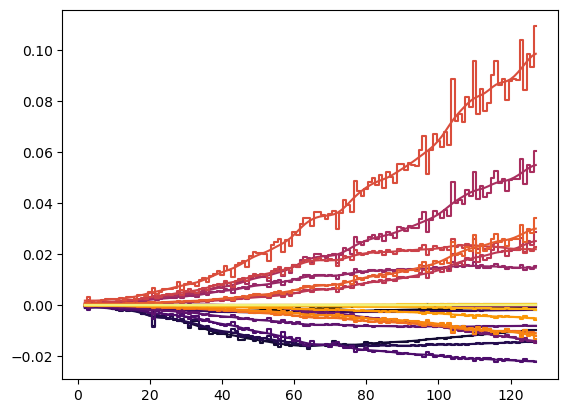

In [206]:
idx_auto = np.zeros(N_freqs, dtype=int)
for i in range(N_freqs):
    idx_auto[i] = cvl.cross_index(i, i, N_freqs)

sm = plt.cm.ScalarMappable(cmap='inferno', norm=plt.Normalize(vmin=0, vmax=N_freqs))

plt.figure(figsize=(6.4, 4.8))
for i in range(N_freqs):
    plt.step(ell, W1_nu_ell[idx_auto[i]], where='mid', color=sm.to_rgba(i))
    plt.plot(ell, W1_nu_ell_smooth[idx_auto[i]], color=sm.to_rgba(i))
plt.show()

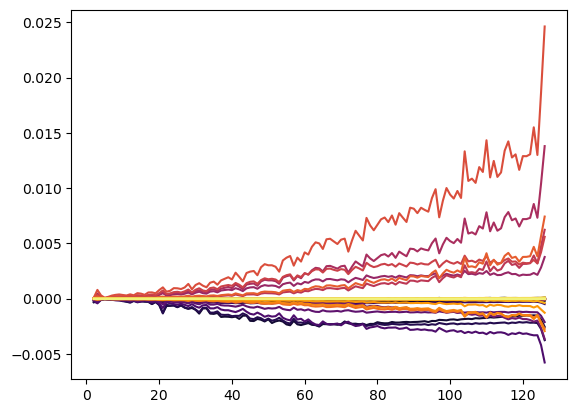

In [207]:
idx_auto = np.zeros(N_freqs, dtype=int)
for i in range(N_freqs):
    idx_auto[i] = cvl.cross_index(i, i, N_freqs)

sm = plt.cm.ScalarMappable(cmap='inferno', norm=plt.Normalize(vmin=0, vmax=N_freqs))

plt.figure(figsize=(6.4, 4.8))
for i in range(N_freqs):
    plt.step(ell[:-1], (W1_cmb[np.arange(Nell-1), idx_auto[i]+Ncross*(np.arange(Nell-1)+1)]), where='mid', color=sm.to_rgba(i))
    plt.plot(ell[:-1], (W1_cmb_smooth[np.arange(Nell-1), idx_auto[i]+Ncross*(np.arange(Nell-1)+1)]), color=sm.to_rgba(i))
#plt.yscale('log')
plt.show()

In [208]:
W1_cmb.shape

(126, 31878)

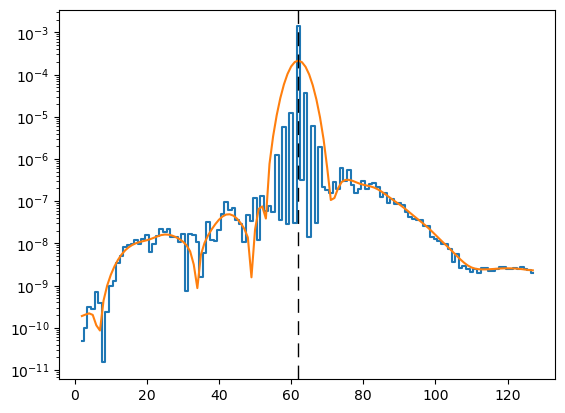

In [209]:
plt.figure(figsize=(6.4, 4.8))
i = 60
for j in range(1):
    j = 0
    plt.step(ell, np.abs(W1_cmb[i, j+Ncross*np.arange(Nell)]), where='mid')
    plt.plot(ell, np.abs(W1_cmb_smooth[i, j+Ncross*np.arange(Nell)]))
plt.axvline(ell[i], ls=(0, (10,6)), lw=1, color='black')
plt.yscale('log')
plt.show()

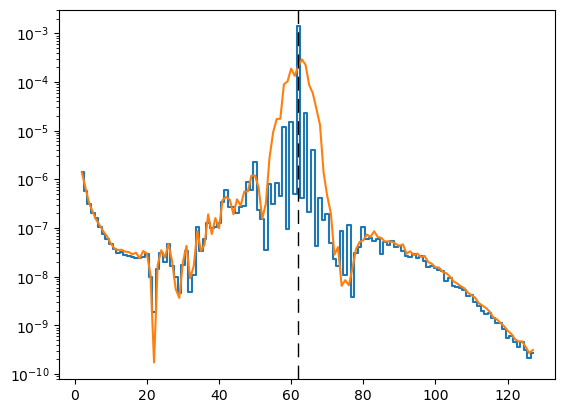

In [210]:
i = 60
j = 0

plt.figure(figsize=(6.4, 4.8))
plt.step(ell, np.abs(W1_cmb[:, j+Ncross*i]), where='mid')
plt.plot(ell, np.abs(W1_cmb_smooth[:, j+Ncross*i]))
plt.axvline(ell[i], ls=(0, (10,6)), lw=1, color='black')
plt.yscale('log')
plt.show()

In [211]:
Dl_cmb1 = np.zeros((N, Nell))
for k in range(N):
    for i in range(Nell):
        Dl_cmb1[k, i] = np.sum(W1_nu_ell[:, i] * data1[k, :, i])

Dl_cmb1_smooth = np.zeros((N, Nell))
for k in range(N):
    for i in range(Nell):
        Dl_cmb1_smooth[k, i] = np.sum(W1_nu_ell_smooth[:, i] * data1[k, :, i])

Dlfull_cmb1 = np.zeros((N, Nell))
for k in range(N):
    Dlfull_cmb1[k] = W1_cmb @ np.concatenate(data1[k].T)

Dlfull_cmb1_smooth = np.zeros((N, Nell))
for k in range(N):
    Dlfull_cmb1_smooth[k] = W1_cmb_smooth @ np.concatenate(data1[k].T)

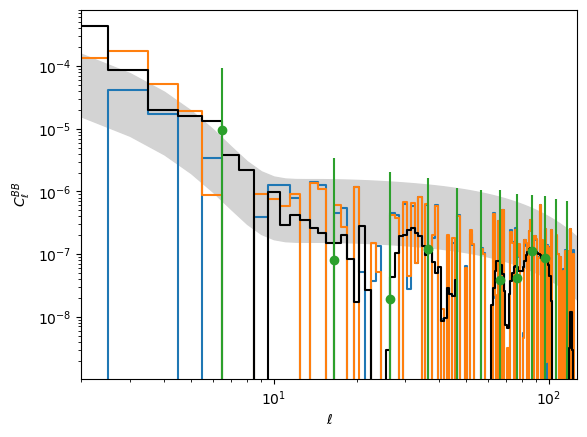

In [212]:
Cl_lens = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')[2, :lmax+1]

Dl_lens = b.bin_cell(Cl_lens)
Dl_lens1 = b1.bin_cell(Cl_lens)

Cl_tens = hp.read_cl('../power_spectra/Cls_Planck2018_tensor_r1.fits')[2, :lmax+1]
Dl_tens = b1.bin_cell(Cl_tens)

plt.figure(figsize=(6.4, 4.8))
plt.fill_between(ell, 1e-3*Dl_tens / ell / (ell+1) * 2*np.pi, 1e-2*Dl_tens / ell / (ell+1) * 2*np.pi, color='lightgrey')

plt.step(ell, (np.mean(Dl_cmb1, axis=0) - Dl_lens1) / ell / (ell+1) * 2*np.pi, where='mid')
#plt.errorbar(ell, np.mean(Dl_cmb1, axis=0) - Dl_lens1, yerr=np.std(Dl_cmb1, axis=0), fmt='o')
plt.step(ell, (np.mean(Dl_cmb1_smooth, axis=0) - Dl_lens1) / ell / (ell+1) * 2*np.pi, where='mid')
#plt.errorbar(ell, np.mean(Dl_cmb1_smooth, axis=0) - Dl_lens1, yerr=np.std(Dl_cmb1_smooth, axis=0), fmt='o')
#plt.step(ell, (np.mean(Dlfull_cmb1, axis=0) - Dl_lens1) / ell / (ell+1) * 2*np.pi, where='mid')
#plt.errorbar(ell, np.mean(Dlfull_cmb1, axis=0) - Dl_lens1, yerr=np.std(Dlfull_cmb1, axis=0), fmt='o')
plt.step(ell, (np.mean(Dlfull_cmb1_smooth, axis=0) - Dl_lens1) / ell / (ell+1) * 2*np.pi, where='mid', color='black')
#plt.errorbar(ell, np.mean(Dlfull_cmb1_smooth, axis=0) - Dl_lens1, yerr=np.std(Dlfull_cmb1_smooth, axis=0), fmt='o')

plt.errorbar(leff, (np.mean(results['cmb'], axis=1) - Dl_lens) / leff / (leff+1) * 2*np.pi, yerr=np.std(results['cmb'], axis=1) / leff / (leff+1) * 2*np.pi, fmt='o')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell^{BB}$')
plt.xlim(min(ell), max(ell))
plt.xscale('log')
plt.yscale('log')
plt.show()

In [213]:
Dl_cmb1_smooth.shape

(250, 126)

In [214]:
# Global fit no marg

Dl_tens = b1.bin_cell(Cl_tens)

cmb = Dlfull_cmb1_smooth.T
cmb = Dl_cmb1.T
#cmb = results1['cmb']

if global_r:
    r_global = np.mean(cmb)
    sigma_r_global = np.std(cmb)
else:
    total_cmb = cmb.T
    cov_cmb = np.cov(cmb)
    N_inv_cmb = np.linalg.inv(cov_cmb)
    
    A_cmb = np.zeros((Nell, 1))
    A_cmb[:, 0] = Dl_tens
    
    W_cmb = np.linalg.inv(A_cmb.T @ N_inv_cmb @ A_cmb) @ A_cmb.T @ N_inv_cmb
    
    samp_nomarg = np.zeros((N, 2))
    chi2r_nomarg = np.zeros(N)
    
    for i in range(N):
        d_cmb = total_cmb[i] - Dl_lens1
        s_cmb = W_cmb @ d_cmb
        
        res = d_cmb - A_cmb @ s_cmb
        dof = len(d_cmb) - len(s_cmb)
        
        samp_nomarg[i, 0] = s_cmb[0]
        chi2r_nomarg[i] = res.T @ N_inv_cmb @ res / dof
    
    samp_nomarg[:, 1] = 100
    
    r_global = np.mean(samp_nomarg[:, 0])
    sigma_r_global = np.std(samp_nomarg[:, 0])

print(f'\nGlobal fit:\n'+
      f'r          = {np.round(r_global, 5)} +/- {np.round(sigma_r_global, 5)}\n'+
      f'bias/sigma = {np.abs(r_global/sigma_r_global)}\n'
     )


Global fit:
r          = 0.00026 +/- 0.00259
bias/sigma = 0.10046860139651809



In [215]:
# Global fit no marg

cmb = results['cmb']

Cl_tens = hp.read_cl('../power_spectra/Cls_Planck2018_tensor_r1.fits')[2, :lmax+1]
Dl_tens = b.bin_cell(Cl_tens)

if global_r:
    r_global = np.mean(cmb)
    sigma_r_global = np.std(cmb)
else:
    total_cmb = cmb.T
    cov_cmb = np.cov(cmb)
    N_inv_cmb = np.linalg.inv(cov_cmb)
    
    A_cmb = np.zeros((Nbins, 1))
    A_cmb[:, 0] = Dl_tens
    
    W_cmb = np.linalg.inv(A_cmb.T @ N_inv_cmb @ A_cmb) @ A_cmb.T @ N_inv_cmb
    
    samp_nomarg = np.zeros((N, 2))
    chi2r_nomarg = np.zeros(N)
    
    for i in range(N):
        d_cmb = total_cmb[i] - Dl_lens
        s_cmb = W_cmb @ d_cmb
        
        res = d_cmb - A_cmb @ s_cmb
        dof = len(d_cmb) - len(s_cmb)
        
        samp_nomarg[i, 0] = s_cmb[0]
        chi2r_nomarg[i] = res.T @ N_inv_cmb @ res / dof
    
    samp_nomarg[:, 1] = 100
    
    r_global = np.mean(samp_nomarg[:, 0])
    sigma_r_global = np.std(samp_nomarg[:, 0])

print(f'\nGlobal fit:\n'+
      f'r          = {np.round(r_global, 5)} +/- {np.round(sigma_r_global, 5)}\n'+
      f'bias/sigma = {np.abs(r_global/sigma_r_global)}\n'
     )


Global fit:
r          = 0.00037 +/- 0.00365
bias/sigma = 0.10129475632617257



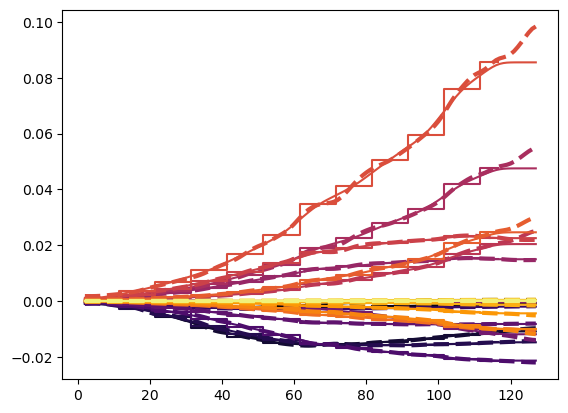

In [217]:
# Interp and smooth binned weights

sigma = 2

W2_nu_ell = np.zeros((Ncross, Nell))
for i in range(Ncross):
    W2_nu_ell[i] = gaussian_filter(np.interp(ell, leff, W_nu_ell[i]), sigma=2, mode='reflect')
        
plt.figure(figsize=(6.4, 4.8))
for i in range(N_freqs):
    plt.step(leff, W_nu_ell[idx_auto[i]], where='mid', color=sm.to_rgba(i))
    plt.plot(ell, W1_nu_ell_smooth[idx_auto[i]], ls='--', lw=3, color=sm.to_rgba(i))
    plt.plot(ell, W2_nu_ell[idx_auto[i]], color=sm.to_rgba(i))
plt.show()

In [218]:
np.sum(W2_nu_ell, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1.])

In [219]:
Dl_cmb2 = np.zeros((N, Nell))
for k in range(N):
    for i in range(Nell):
        Dl_cmb2[k, i] = np.sum(W2_nu_ell[:, i] * data1[k, :, i])

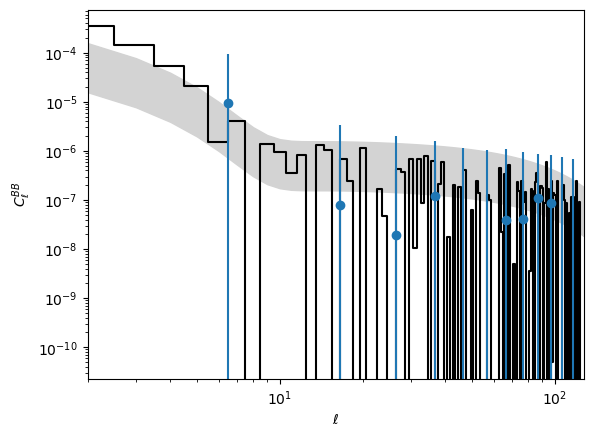

In [220]:
Cl_lens = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')[2, :lmax+1]

Dl_lens = b.bin_cell(Cl_lens)
Dl_lens1 = b1.bin_cell(Cl_lens)

Cl_tens = hp.read_cl('../power_spectra/Cls_Planck2018_tensor_r1.fits')[2, :lmax+1]
Dl_tens = b1.bin_cell(Cl_tens)

plt.figure(figsize=(6.4, 4.8))
plt.fill_between(ell, 1e-3*Dl_tens / ell / (ell+1) * 2*np.pi, 1e-2*Dl_tens / ell / (ell+1) * 2*np.pi, color='lightgrey')

plt.step(ell, (np.mean(Dl_cmb2, axis=0) - Dl_lens1) / ell / (ell+1) * 2*np.pi, where='mid', color='black')
#plt.errorbar(ell, np.mean(Dl_cmb2, axis=0) - Dl_lens1, yerr=np.std(Dl_cmb2, axis=0), fmt='o', color='black')

plt.errorbar(leff, (np.mean(results['cmb'], axis=1) - Dl_lens) / leff / (leff+1) * 2*np.pi, yerr=np.std(results['cmb'], axis=1) / leff / (leff+1) * 2*np.pi, fmt='o')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell^{BB}$')
plt.xlim(min(ell), max(ell))
plt.xscale('log')
plt.yscale('log')
plt.show()

In [221]:
# Global fit no marg

Dl_tens = b1.bin_cell(Cl_tens)

cmb = Dl_cmb2.T

if global_r:
    r_global = np.mean(cmb)
    sigma_r_global = np.std(cmb)
else:
    total_cmb = cmb.T
    cov_cmb = np.cov(cmb)
    N_inv_cmb = np.linalg.inv(cov_cmb)
    
    A_cmb = np.zeros((Nell, 1))
    A_cmb[:, 0] = Dl_tens
    
    W_cmb = np.linalg.inv(A_cmb.T @ N_inv_cmb @ A_cmb) @ A_cmb.T @ N_inv_cmb
    
    samp_nomarg = np.zeros((N, 2))
    chi2r_nomarg = np.zeros(N)
    
    for i in range(N):
        d_cmb = total_cmb[i] - Dl_lens1
        s_cmb = W_cmb @ d_cmb
        
        res = d_cmb - A_cmb @ s_cmb
        dof = len(d_cmb) - len(s_cmb)
        
        samp_nomarg[i, 0] = s_cmb[0]
        chi2r_nomarg[i] = res.T @ N_inv_cmb @ res / dof
    
    samp_nomarg[:, 1] = 100
    
    r_global = np.mean(samp_nomarg[:, 0])
    sigma_r_global = np.std(samp_nomarg[:, 0])

print(f'\nGlobal fit:\n'+
      f'r          = {np.round(r_global, 5)} +/- {np.round(sigma_r_global, 5)}\n'+
      f'bias/sigma = {np.abs(r_global/sigma_r_global)}\n'
     )


Global fit:
r          = 0.00029 +/- 0.0026
bias/sigma = 0.1113942826919213



In [222]:
ell_trans = 28
delta_ell = 10

ell_ini = np.concatenate((np.arange(2, ell_trans), np.arange(ell_trans, lmax+1, delta_ell)))
ell_end = np.concatenate((np.arange(2, ell_trans)+1, np.arange(ell_trans, lmax+1, delta_ell)+delta_ell))
ell_end = ell_end[ell_end <= lmax+1]
ell_ini = ell_ini[:len(ell_end)]

print(ell_ini)
print(ell_end)

[  2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  25  26  27  28  38  48  58  68  78  88  98 108 118]
[  3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20
  21  22  23  24  25  26  27  28  38  48  58  68  78  88  98 108 118 128]


In [223]:
btest = nmt.NmtBin.from_edges(ell_ini, ell_end, is_Dell=True)
ltest = btest.get_effective_ells()
Dl_lenstest = btest.bin_cell((Cl_lens + 1e-2*Cl_tens)[:ell_end[-1]])

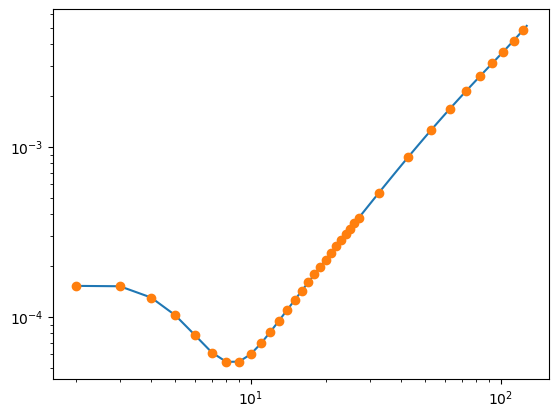

In [224]:
plt.figure(figsize=(6.4, 4.8))
plt.plot(ell, Dl_lens1 + 1e-2*Dl_tens)
plt.plot(ltest, Dl_lenstest, 'o')
plt.xscale('log')
plt.yscale('log')
plt.show()

In [225]:
ltest

array([  2. ,   3. ,   4. ,   5. ,   6. ,   7. ,   8. ,   9. ,  10. ,
        11. ,  12. ,  13. ,  14. ,  15. ,  16. ,  17. ,  18. ,  19. ,
        20. ,  21. ,  22. ,  23. ,  24. ,  25. ,  26. ,  27. ,  32.5,
        42.5,  52.5,  62.5,  72.5,  82.5,  92.5, 102.5, 112.5, 122.5])

In [226]:
len(ltest)

36

In [227]:
btest.get_effective_ells()

array([  2. ,   3. ,   4. ,   5. ,   6. ,   7. ,   8. ,   9. ,  10. ,
        11. ,  12. ,  13. ,  14. ,  15. ,  16. ,  17. ,  18. ,  19. ,
        20. ,  21. ,  22. ,  23. ,  24. ,  25. ,  26. ,  27. ,  32.5,
        42.5,  52.5,  62.5,  72.5,  82.5,  92.5, 102.5, 112.5, 122.5])

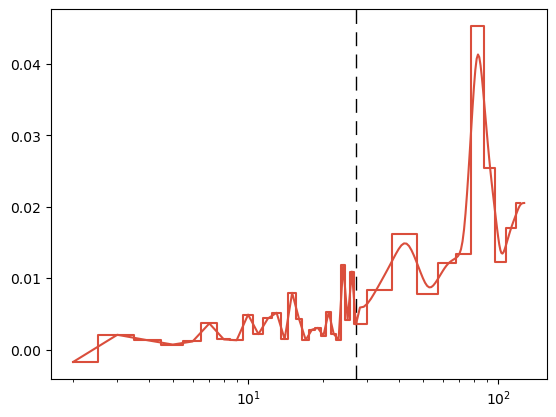

In [486]:
# Smooth baseline weights

W_nu_ell = np.load('weights_medium.npy')

W1_nu_ell = np.zeros((Ncross, Nell))
for i in range(Ncross):
    W1_nu_ell[i, :ell_trans-2] = gaussian_filter(np.interp(ell, ltest, W_nu_ell[i]), sigma=0, mode='reflect')[:ell_trans-2]
    W1_nu_ell[i, ell_trans-2:] = gaussian_filter(np.interp(ell, ltest, W_nu_ell[i]), sigma=2, mode='reflect')[ell_trans-2:]

plt.figure(figsize=(6.4, 4.8))
plt.axvline(ell[ell_trans-3], ls=(0, (10,6)), lw=1, color='black')
plt.xscale('log')
for i in range(1):
    i = 13
    plt.step(ltest, W_nu_ell[idx_auto[i]], where='mid', color=sm.to_rgba(i))
    plt.plot(ell, W1_nu_ell[idx_auto[i]], color=sm.to_rgba(i))
plt.show()

In [422]:
np.sum(W_nu_ell, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1.])

In [423]:
np.sum(W1_nu_ell, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1.])

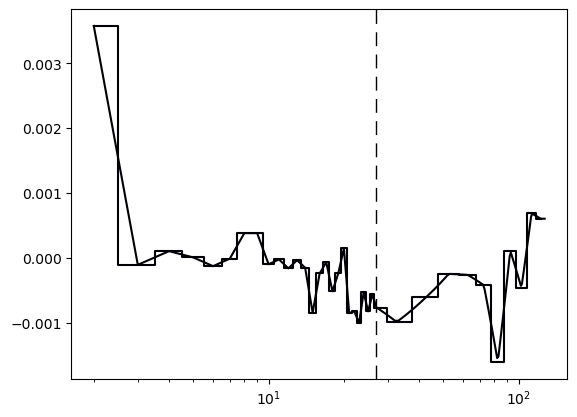

In [799]:
# Smooth baseline weights

complexity = 'high'

data1 = np.load(Pathload+'/power_spectra/DLcross_nside%s_fsky%s_scale%s_Nlbin%s_d%ss%sc' % (nside, fsky, scale, 1, complexity[0], complexity[0])+kws+'.npy')[:, :, :Nell]
W_nu_ell = np.load(f'weights_{complexity}.npy')

W1_nu_ell = np.zeros((Ncross, Nell))
for i in range(Ncross):
    W1_nu_ell[i, :ell_trans-2] = gaussian_filter(np.interp(ell, ltest, W_nu_ell[i]), sigma=0, mode='reflect')[:ell_trans-2]

    for j in range(ell_trans-2, Nell):
        idx = np.argmin(np.abs(ell[j] - ltest))
        W1_nu_ell[i, j] = W_nu_ell[i, idx]
    
    W1_nu_ell[i, ell_trans-2:] = gaussian_filter(W1_nu_ell[i], sigma=5)[ell_trans-2:]
    W1_nu_ell[i, ell_trans-2:] = gaussian_filter(np.interp(ell, ltest, W_nu_ell[i]), sigma=0, mode='reflect')[ell_trans-2:]

plt.figure(figsize=(6.4, 4.8))
plt.axvline(ell[ell_trans-3], ls=(0, (10,6)), lw=1, color='black')
plt.xscale('log')
for i in range(1):
    i = 0
    plt.step(ltest, W_nu_ell[idx_auto[i]], where='mid', color=sm.to_rgba(i))
    plt.plot(ell, W1_nu_ell[idx_auto[i]], color=sm.to_rgba(i))
plt.show()

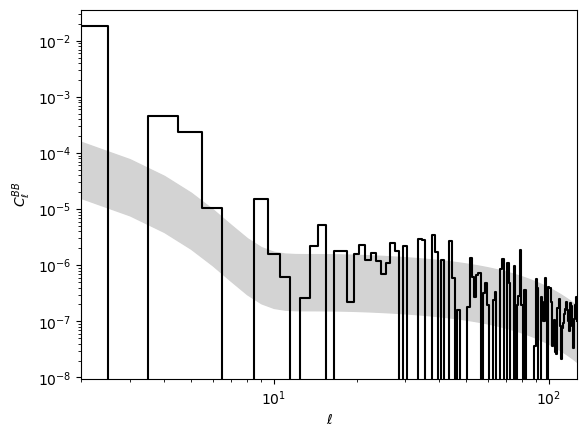

In [800]:
Dl_cmb = np.zeros((N, Nell))
for k in range(N):
    for i in range(Nell):
        Dl_cmb[k, i] = np.sum(W1_nu_ell[:, i] * data1[k, :, i])

Cl_lens = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')[2, :lmax+1]
Dl_lens1 = b1.bin_cell(Cl_lens)

Cl_tens = hp.read_cl('../power_spectra/Cls_Planck2018_tensor_r1.fits')[2, :lmax+1]
Dl_tens = b1.bin_cell(Cl_tens)

plt.figure(figsize=(6.4, 4.8))
plt.fill_between(ell, 1e-3*Dl_tens / ell / (ell+1) * 2*np.pi, 1e-2*Dl_tens / ell / (ell+1) * 2*np.pi, color='lightgrey')

plt.step(ell, (np.mean(Dl_cmb, axis=0) - Dl_lens1) / ell / (ell+1) * 2*np.pi, where='mid', color='black')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell^{BB}$')
plt.xlim(min(ell), max(ell))
plt.xscale('log')
plt.yscale('log')
plt.show()

In [801]:
# Global fit no marg

Dl_tens = b1.bin_cell(Cl_tens)

cmb = Dl_cmb.T

if global_r:
    r_global = np.mean(cmb)
    sigma_r_global = np.std(cmb)
else:
    total_cmb = cmb.T
    cov_cmb = np.cov(cmb)
    N_inv_cmb = np.linalg.inv(cov_cmb)
    
    A_cmb = np.zeros((Nell, 1))
    A_cmb[:, 0] = Dl_tens
    
    W_cmb = np.linalg.inv(A_cmb.T @ N_inv_cmb @ A_cmb) @ A_cmb.T @ N_inv_cmb
    
    samp_nomarg = np.zeros((N, 2))
    chi2r_nomarg = np.zeros(N)
    
    for i in range(N):
        d_cmb = total_cmb[i] - Dl_lens1
        s_cmb = W_cmb @ d_cmb
        
        res = d_cmb - A_cmb @ s_cmb
        dof = len(d_cmb) - len(s_cmb)
        
        samp_nomarg[i, 0] = s_cmb[0]
        chi2r_nomarg[i] = res.T @ N_inv_cmb @ res / dof
    
    samp_nomarg[:, 1] = 100
    
    r_global = np.mean(samp_nomarg[:, 0])
    sigma_r_global = np.std(samp_nomarg[:, 0])

print(f'\nGlobal fit:\n'+
      f'r          = {np.round(r_global, 5)} +/- {np.round(sigma_r_global, 5)}\n'+
      f'bias/sigma = {np.abs(r_global/sigma_r_global)}\n'
     )


Global fit:
r          = 0.0036 +/- 0.00163
bias/sigma = 2.206759080550266

